## Лабораторная работа 10. Вариант 2_1. МакеевГБ

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента – автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата – ответ на задание в LMS в виде двух файлов:
* ноутбук в формате **ipynb**, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате **html**, полученный путем экспорта ноутбука из п. 1.

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (ответов в текстовых ячейках, программного кода и комментариев к нему).   
   *  Ответы в текстовых ячейках на поставленные вопросы **обязательны для получения баллов** за проверочный тест.  
   *  Все выводимые на консоль значения должны быть **подписаны**.   
   *  Построенные графики должны быть хорошо читаемыми, иметь корректные названия и названия осей.   
    *  На графике с несколькими цветами **обязательна легенда** для идентификации каждого цвета.
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 10 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт библиотеки *NumPy* и модуля *Pyplot* библиотеки *Matplotlib*, а также подключить инструментарий для разбиения набора данных на обучающее/тестовое множество из библиотеки *Sciktit-learn*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Остальной необходимый для работы инструментарий подключать в тех кодовых ячейках, где он впервые используется.

### Задание 2

Сгенерировать модельный набор данных для задачи бинарной классификации по двум признакам, используя метод *make_blobs*. При генерации указать параметры:
*   общее количество объектов – 260,
*   параметр, определяющий рассеивание точек (*cluster_std*) – 3.8,
*   *random_state* – 63.

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=260,
    centers=2,
    n_features=2,
    cluster_std=3.8,
    random_state=63
)

print(f"Размер матрицы признаков: {X.shape}")
print(f"Размер вектора меток: {y.shape}")

Размер матрицы признаков: (260, 2)
Размер вектора меток: (260,)


Вывести сгенерированные значения признаков и метку класса для первых 7 объектов. Значения признаков округлить до 3 знаков после запятой.

In [3]:
print("Первые 7 объектов с метками классов:")
for i in range(7):
    print(
        f"{i + 1}: x1 = {X[i, 0]:.3f}, "
        f"x2 = {X[i, 1]:.3f}, "
        f"class = {y[i]}"
    )

Первые 7 объектов с метками классов:
1: x1 = 4.545, x2 = 0.708, class = 0
2: x1 = 2.774, x2 = -1.081, class = 0
3: x1 = -10.050, x2 = -2.407, class = 1
4: x1 = -0.890, x2 = -1.553, class = 1
5: x1 = -4.291, x2 = 2.757, class = 1
6: x1 = 7.122, x2 = 3.732, class = 0
7: x1 = 0.693, x2 = -5.364, class = 0


Проверить сбалансированность классов в сгенерированном наборе, вычислив доли объектов, относящихся к каждому из классов.

In [4]:
classes, counts = np.unique(y, return_counts=True)
shares = counts / len(y)

for cls, share in zip(classes, shares):
    print(f"Доля объектов класса {cls}: {share:.3f}")

Доля объектов класса 0: 0.500
Доля объектов класса 1: 0.500


Ответить на вопрос: является ли задача бинарной классификации сбалансированной или наблюдается дисбаланс классов?

__*Ваш ответ:*__

Задача является **сбалансированной**, так как оба класса представлены одинаково: по 130 объектов, то есть доля каждого класса равна **0.500**.

Выполнить визуализацию сгенерированного набора данных в виде диаграммы рассеяния, изобразив объекты, относящиеся к разным классам, разными цветами.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов можно оставить «по умолчанию» или же настроить свой, используя *ListedColormap*.

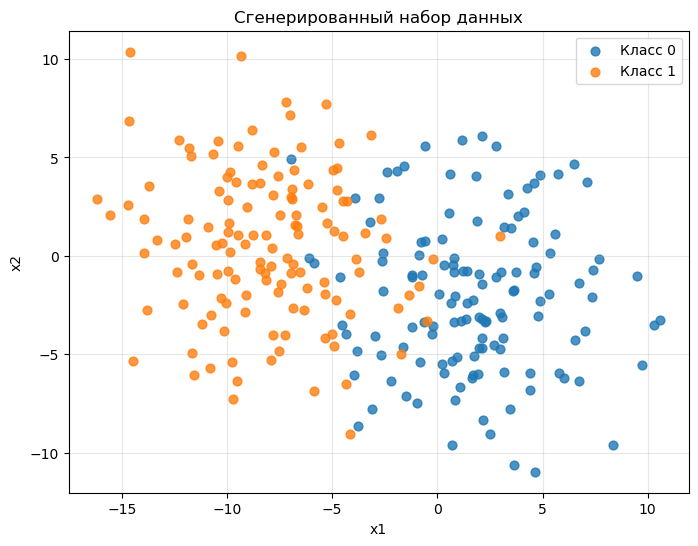

In [5]:
plt.figure(figsize=(8, 6))

for cls in np.unique(y):
    mask = y == cls
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        s=40,
        alpha=0.8,
        label=f"Класс {cls}"
    )

plt.title("Сгенерированный набор данных")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

По результатам визуализации ответить на вопросы:

* в каких областях пространства модель логистической регрессии будет предсказывать вероятность, близкую к 1? к 0?

*  где будут находиться объекты, которым модель логистической регрессии будет предсказывать вероятность около 0.5?

* как будет выглядеть разделяющая классы граница при использовании модели логистической регрессии?


__*Ваши ответы:*__

* Вероятность, близкую к 1, модель будет давать в области скопления объектов класса 1. Вероятность, близкую к 0, — в области скопления объектов класса 0.

* Вероятность около 0.5 будут получать точки, расположенные рядом с границей между двумя облаками классов.

* Разделяющая граница у логистической регрессии будет **прямой линией**, потому что модель линейна по признакам до применения сигмоиды.

### Задание 3

Выполнить разбиение сгенерированного набора данных на обучающую и тестовую выборки в соотношении 85/15. При разбиении задать *random_state* = 63.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=63
)

Вывести для ознакомления информацию о полученных выборках:
*   определить количество объектов в обучающей и тестовой выборках;
*   проверить баланс классов в обучающей и тестовой выборках, определив доли каждого класса. Полученные значения округлить до 3 знаков после запятой.



In [7]:
print(f"Количество объектов в обучающей выборке: {len(X_train)}")
print(f"Количество объектов в тестовой выборке: {len(X_test)}")

Количество объектов в обучающей выборке: 221
Количество объектов в тестовой выборке: 39


In [8]:
for sample_name, target in [("обучающей", y_train), ("тестовой", y_test)]:
    classes, counts = np.unique(target, return_counts=True)
    shares = counts / len(target)
    print(f"Доли классов в {sample_name} выборке:")
    for cls, share in zip(classes, shares):
        print(f"  класс {cls}: {share:.3f}")

Доли классов в обучающей выборке:
  класс 0: 0.516
  класс 1: 0.484
Доли классов в тестовой выборке:
  класс 0: 0.410
  класс 1: 0.590


Ответить на вопрос: получившееся соотношение классов в обучающей и тестовой выборке близко к исходному соотношению классов в сгенерированном наборе данных или нет?

__*Ваш ответ:*__

Да, получившееся соотношение классов **близко к исходному**. Изначально доли были 0.500 и 0.500, после разбиения получились 0.516/0.484 для обучающей выборки и 0.410/0.590 для тестовой. Отклонение связано со случайным разбиением без стратификации.

**Замечание**. В общем случае перед обучением логистической регрессии требуется провести масштабирование числовых признаков. Однако в данных, сгенерированных с помощью *make_blobs*, признаки уже имеют сопоставимые масштабы и близкие характеристики разброса, поэтому в данном случае масштабирование не требуется.

### Задание 4

Импортировать инструментарий, необходимый для построения модели логистической регрессии. Создать модель с $L_2$-регуляризацией и коэффициентом регуляризации $\lambda = 20$.

In [9]:
from sklearn.linear_model import LogisticRegression

lambda_reg = 20
model = LogisticRegression(C=1 / lambda_reg, max_iter=1000)
model.fit(X_train, y_train)

print(f"Модель обучена. Использовано значение C = {model.C:.3f}")

Модель обучена. Использовано значение C = 0.050


Получить коэффициенты обученной модели. Вывести полученные значения, округлив их до 2 знаков после запятой.

**Указание**. Не забыть про свободный коэффициент модели.

In [10]:
w0 = model.intercept_[0]
w1, w2 = model.coef_[0]

print(f"Свободный коэффициент w0 = {w0:.2f}")
print(f"Коэффициент w1 = {w1:.2f}")
print(f"Коэффициент w2 = {w2:.2f}")

Свободный коэффициент w0 = -2.42
Коэффициент w1 = -0.70
Коэффициент w2 = 0.08


Записать уравнение обученной модели логистической регрессии в формате $\pi(x) = \dfrac {1}{1+e^{- \left ( w_0 + w_1 \cdot x^1 + w_2 \cdot x^2 \right )}}$.

__*Ваш ответ:*__

$$
\pi(x) = \frac{1}{1 + e^{-\left(-2.42 - 0.70 \cdot x^1 + 0.08 \cdot x^2\right)}}
$$

Ответить на вопросы:

*  что предсказывает модель логистической регресии?

*  какое предсказание будет получено при больших положительных значениях $w_0 + w_1 \cdot x^1 + w_2 \cdot x^2$? При больших отрицательных? При близких к 0?

*  как знак коэффициента влияет на предсказание модели?

__*Ваши ответы:*__

* Модель логистической регрессии предсказывает **вероятность принадлежности объекта к классу 1**. По выбранному порогу эта вероятность затем переводится в метку класса.

* При больших положительных значениях линейной комбинации вероятность стремится к 1, при больших отрицательных — к 0, а при значениях, близких к 0, вероятность близка к 0.5.

* Положительный коэффициент увеличивает вероятность класса 1 при росте признака, отрицательный — уменьшает.

Вывести объект обучающей выборки с индексом 130, округлив значения значения признаков до 2 знаков после запятой.

In [11]:
obj_130 = X_train[130]

print(f"Объект с индексом 130: x1 = {obj_130[0]:.2f}, x2 = {obj_130[1]:.2f}")
print(f"Истинная метка класса: {y_train[130]}")

Объект с индексом 130: x1 = -2.76, x2 = 2.92
Истинная метка класса: 0


Используя записанную формулу обученной модели логистической регрессии определить проноз модели для данного объекта «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.


__*Ваш ответ:*__

Для объекта $x = (-2.76; 2.92)$ используем уравнение

$$
\pi(x) = \frac{1}{1 + e^{-\left(-2.42 - 0.70 \cdot x^1 + 0.08 \cdot x^2\right)}}
$$

Сначала вычислим линейную комбинацию:

$$
z = -2.42 - 0.70 \cdot (-2.76) + 0.08 \cdot (2.92) = -0.254
$$

Тогда

$$
\pi(x) = \frac{1}{1 + e^{-(-0.254)}} \approx 0.437
$$

Следовательно, вероятность принадлежности объекта к классу 1 приблизительно равна **0.437**.

Записать правило прогнозирования метки класса объекта для значения порога вероятности 0,5.

__*Ваш ответ:*__

Если $\pi(x) \ge 0.5$, объект относим к классу 1. Если $\pi(x) < 0.5$, объект относим к классу 0.

Используя записанное правило прогнозирования метки класса и получить прогнозируемую метку класса для объекта с индексом 130 «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.

***Ваш ответ:***

Для объекта с индексом 130 получено $\pi(x) \approx 0.437$. Так как $0.437 < 0.5$, прогнозируемая метка класса равна **0**.

Какую прогнозируемую метку класса получил бы данный объект, если бы в правиле  прогнозирования метки класса использовался порог 0,3?

__*Ваш ответ:*__

При пороге 0.3 данный объект получил бы метку **1**, так как $\pi(x) \approx 0.437 > 0.3$.

Для обучающей выборки получить предсказания обученной модели и пронозируемые метки классов.

In [12]:
train_proba = model.predict_proba(X_train)[:, 1]
y_pred_train = (train_proba >= 0.5).astype(int)

print("Вероятности класса 1 и прогнозируемые метки для обучающей выборки получены.")

Вероятности класса 1 и прогнозируемые метки для обучающей выборки получены.


Вывести обученной модели и пронозируемые метки классов для первых 7 объектов обучающей выборки. Значения вероятностей округлить до 3 знаков после запятой.

In [13]:
print("Первые 7 объектов обучающей выборки:")
for i in range(7):
    print(
        f"{i + 1}: x1 = {X_train[i, 0]:.3f}, "
        f"x2 = {X_train[i, 1]:.3f}, "
        f"true_class = {y_train[i]}, "
        f"p(class=1) = {train_proba[i]:.3f}, "
        f"pred_class = {y_pred_train[i]}"
    )

Первые 7 объектов обучающей выборки:
1: x1 = -6.721, x2 = 2.077, true_class = 1, p(class=1) = 0.919, pred_class = 1
2: x1 = -6.949, x2 = 4.932, true_class = 0, p(class=1) = 0.943, pred_class = 1
3: x1 = 3.635, x2 = -1.739, true_class = 0, p(class=1) = 0.006, pred_class = 0
4: x1 = -3.876, x2 = -0.146, true_class = 1, p(class=1) = 0.567, pred_class = 1
5: x1 = -2.612, x2 = -0.269, true_class = 0, p(class=1) = 0.349, pred_class = 0
6: x1 = 2.272, x2 = -3.387, true_class = 0, p(class=1) = 0.014, pred_class = 0
7: x1 = -6.625, x2 = 1.121, true_class = 1, p(class=1) = 0.908, pred_class = 1


Дать оценку уверенности модели в принадлежности объекта к прогнозируемому классу для данных объектов.

__*Ваш ответ:*__

Большинство прогнозов сделаны с **высокой уверенностью**, так как вероятности далеки от 0.5. Наименее уверенные прогнозы у 4-го и 5-го объектов из таблицы, потому что их вероятности ближе всего к порогу. При этом 2-й объект модель классифицировала **ошибочно, но уверенно**.

### Задание 5

Вычислить долю правильных ответов, точность, полноту и *F*-меру на обучающей выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

print(f"Accuracy на обучающей выборке: {accuracy_train:.3f}")
print(f"Precision на обучающей выборке: {precision_train:.3f}")
print(f"Recall на обучающей выборке: {recall_train:.3f}")
print(f"F1-мера на обучающей выборке: {f1_train:.3f}")

Accuracy на обучающей выборке: 0.955
Precision на обучающей выборке: 0.945
Recall на обучающей выборке: 0.963
F1-мера на обучающей выборке: 0.954


Вычислить долю правильных ответов, точность, полноту и *F*-меру на тестовой выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [15]:
test_proba = model.predict_proba(X_test)[:, 1]
y_pred_test = (test_proba >= 0.5).astype(int)

accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print(f"Accuracy на тестовой выборке: {accuracy_test:.3f}")
print(f"Precision на тестовой выборке: {precision_test:.3f}")
print(f"Recall на тестовой выборке: {recall_test:.3f}")
print(f"F1-мера на тестовой выборке: {f1_test:.3f}")

Accuracy на тестовой выборке: 0.821
Precision на тестовой выборке: 0.944
Recall на тестовой выборке: 0.739
F1-мера на тестовой выборке: 0.829


Дать интерпретацию полученным значениям метрик на тестовой выборке (с пояснением того, какую величину измеряет каждая метрика).

__*Ваши ответы:*__

* **Accuracy = 0.821** означает, что модель правильно классифицирует около 82.1% объектов тестовой выборки.

* **Precision = 0.944** показывает, какая доля объектов, предсказанных как класс 1, действительно относится к классу 1.

* **Recall = 0.739** показывает, какую долю всех реальных объектов класса 1 модель смогла найти.

* **F1 = 0.829** отражает баланс между точностью и полнотой; значение говорит о хорошем, но не идеальном балансе.

Дать оценку качества классификации.

__*Ваш ответ:*__

Качество классификации можно оценить как **хорошее**. Модель даёт высокую точность и неплохую F1-меру, но полнота ниже, поэтому часть объектов класса 1 она всё же пропускает.

### Задание 6

Для порога вероятности, равного 0,3, получить и визуализировать матрицу ошибок на тестовой выборке.

**Указание**. Сначала нужно получить прогнозируемые метки классов для объектов тестовой выборки, реализовав правило правило прогнозирования для указанного порога.

Матрица ошибок на тестовой выборке при пороге 0.3:
[[13  3]
 [ 3 20]]


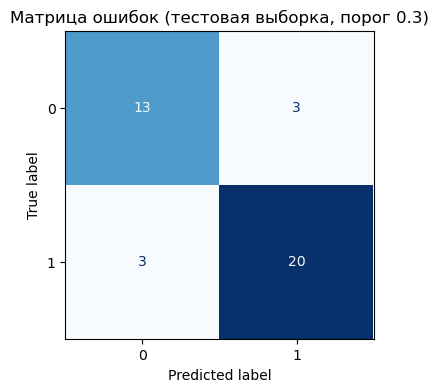

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.3
y_pred_test_03 = (test_proba >= threshold).astype(int)
cm_test_03 = confusion_matrix(y_test, y_pred_test_03)

print("Матрица ошибок на тестовой выборке при пороге 0.3:")
print(cm_test_03)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_03, display_labels=[0, 1])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Матрица ошибок (тестовая выборка, порог 0.3)")
ax.grid(False)
plt.show()

Используя построенную матрицу ошибок, вычислить значения $FPR$ и $TPR$ «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.


__*Ваш ответ:*__

Из матрицы ошибок получаем: $TN = 13$, $FP = 3$, $FN = 3$, $TP = 20$.

Тогда

$$
FPR = \frac{FP}{FP + TN} = \frac{3}{3 + 13} = \frac{3}{16} \approx 0.188
$$

$$
TPR = \frac{TP}{TP + FN} = \frac{20}{20 + 3} = \frac{20}{23} \approx 0.870
$$

Получить значения $FPR$ и $TPR$, а также значения порогов вероятности, использованных для их рассчета, на обучающей и тестовой выборках отдельно.

In [17]:
from sklearn.metrics import roc_curve

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, train_proba)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, test_proba)

print("ROC-параметры для обучающей и тестовой выборок получены.")
print(f"Количество порогов для обучающей выборки: {len(thresholds_train)}")
print(f"Количество порогов для тестовой выборки: {len(thresholds_test)}")

ROC-параметры для обучающей и тестовой выборок получены.
Количество порогов для обучающей выборки: 20
Количество порогов для тестовой выборки: 12


Вывести полученные значения порогов, $FPR$ и $TPR$ на тестовой выборке.

In [18]:
print("Пороги, FPR и TPR для тестовой выборки:")
for threshold, fpr, tpr in zip(thresholds_test, fpr_test, tpr_test):
    threshold_text = "inf" if np.isinf(threshold) else f"{threshold:.3f}"
    print(f"threshold = {threshold_text}, FPR = {fpr:.3f}, TPR = {tpr:.3f}")

Пороги, FPR и TPR для тестовой выборки:
threshold = inf, FPR = 0.000, TPR = 0.000
threshold = 1.000, FPR = 0.000, TPR = 0.043
threshold = 0.653, FPR = 0.000, TPR = 0.652
threshold = 0.614, FPR = 0.062, TPR = 0.652
threshold = 0.530, FPR = 0.062, TPR = 0.739
threshold = 0.469, FPR = 0.188, TPR = 0.739
threshold = 0.165, FPR = 0.188, TPR = 0.913
threshold = 0.121, FPR = 0.375, TPR = 0.913
threshold = 0.088, FPR = 0.375, TPR = 0.957
threshold = 0.013, FPR = 0.625, TPR = 0.957
threshold = 0.012, FPR = 0.625, TPR = 1.000
threshold = 0.000, FPR = 1.000, TPR = 1.000


Построить $ROC$-кривые на обучающей и тестовой выборках (на одном графике).

**Указание**. Не забыть про легенду.

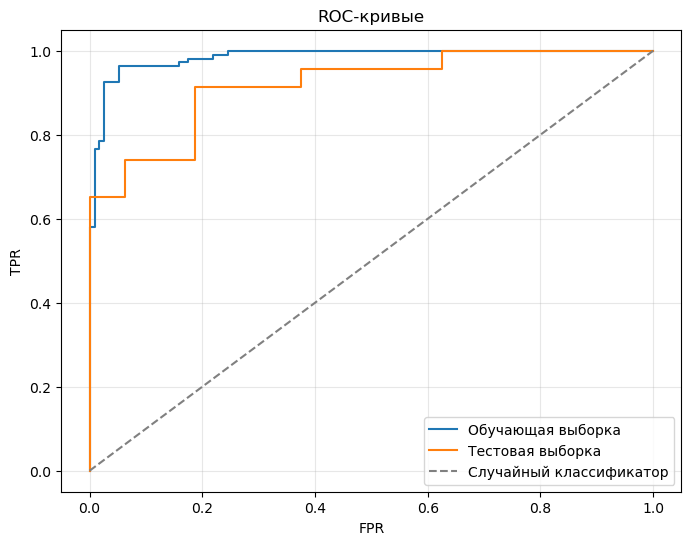

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label="Обучающая выборка")
plt.plot(fpr_test, tpr_test, label="Тестовая выборка")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Случайный классификатор")

plt.title("ROC-кривые")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Оценить качество прогноза вероятности принадлежности классу по полученным кривым.

__*Ваш ответ:*__

Обе ROC-кривые расположены заметно выше диагонали случайного классификатора, значит модель хорошо ранжирует объекты по вероятности принадлежности к классу 1. Кривая на обучающей выборке немного выше тестовой, но сильного ухудшения качества на тесте нет.

 Найти значения метрики $AUC-ROC$ на обучающей и тестовой выборках. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [20]:
from sklearn.metrics import roc_auc_score

auc_train = roc_auc_score(y_train, train_proba)
auc_test = roc_auc_score(y_test, test_proba)

print(f"AUC-ROC на обучающей выборке: {auc_train:.3f}")
print(f"AUC-ROC на тестовой выборке: {auc_test:.3f}")

AUC-ROC на обучающей выборке: 0.985
AUC-ROC на тестовой выборке: 0.918


Дать интерпретацию полученным значениям метрики (с пояснением того, какую величину измеряет метрика). Оценить качество прогноза вероятности принадлежности классу по полученным значениям метрики.

__*Ваш ответ:*__

Метрика **AUC-ROC** измеряет способность модели ранжировать объекты: насколько часто случайный объект класса 1 получает более высокий прогноз вероятности, чем случайный объект класса 0.

В данной работе получены значения **0.985** на обучающей выборке и **0.918** на тестовой. Оба значения высокие, особенно на тестовой выборке (выше 0.9), поэтому качество прогноза вероятности можно считать **очень хорошим**.